<a href="https://colab.research.google.com/github/aryanp2107/100-Day-ML-Challenge-/blob/main/Day54_Text_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Autoregressive Language Models

In [48]:
"""
AUTOREGRESSIVE LANGUAGE MODELS

Key idea: Predict the NEXT token given all PREVIOUS tokens.

P(x_1, x_2, ..., x_n) = P(x_1) × P(x_2|x_1) × P(x_3|x_1,x_2) × ...

Example:
  Input:  "To be or not to"
  Output: "be" (predicted next token)

Training:
  Input:  [To] [be] [or] [not] [to]
  Target: [be] [or] [not] [to] [be]

  (Each position predicts the next token)

Generation (autoregressive):
  1. Input: "To be"
  2. Predict: "or" → "To be or"
  3. Predict: "not" → "To be or not"
  4. Predict: "to" → "To be or not to"
  5. Continue...

This is how GPT, ChatGPT, etc. work!
"""

Casual Masking

In [48]:
"""
CAUSAL MASKING

Problem: In self-attention, each token can see ALL other tokens.
         But for generation, we can only see PAST tokens!

Solution: Mask future tokens in attention.

Regular attention (BERT-style):
  Position 3 sees: [1, 2, 3, 4, 5] ← all positions

Causal attention (GPT-style):
  Position 3 sees: [1, 2, 3, -, -] ← only past & current

Causal mask (lower triangular):
         Pos 1  Pos 2  Pos 3  Pos 4  Pos 5
  Pos 1    1      0      0      0      0
  Pos 2    1      1      0      0      0
  Pos 3    1      1      1      0      0
  Pos 4    1      1      1      1      0
  Pos 5    1      1      1      1      1

  1 = can attend, 0 = masked (can't see)
"""

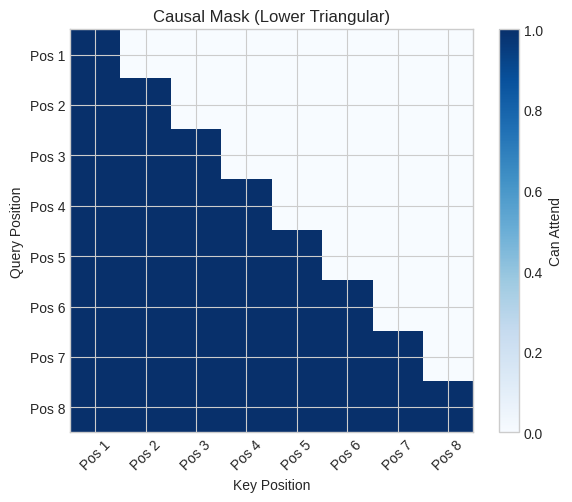

In [4]:
def create_causal_mask(seq_len):
    mask = np.tril(np.ones((seq_len, seq_len)))
    return mask

mask = create_causal_mask(8)

plt.figure(figsize=(6, 5))
plt.imshow(mask, cmap='Blues')
plt.colorbar(label='Can Attend')
plt.xlabel('Key Position')
plt.ylabel('Query Position')
plt.title('Causal Mask (Lower Triangular)')
plt.xticks(range(8), [f'Pos {i+1}' for i in range(8)], rotation=45)
plt.yticks(range(8), [f'Pos {i+1}' for i in range(8)])
plt.tight_layout()
plt.show()

#Each position can only attach to itself and previous positions

In [5]:
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
filepath = "shakespeare.txt"

if not os.path.exists(filepath):
    print("Downloading Shakespeare...")
    urllib.request.urlretrieve(url, filepath)
    print("Download complete!")

with open(filepath, 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Total characters: {len(text):,}")
print(f"\nFirst 500 characters:")
print("="*50)
print(text[:500])

Download complete!
Total characters: 1,115,394

First 500 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [6]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

print(f"Total unique characters: {vocab_size}")
print(f"\nCharacters: {''.join(chars)}")

Total unique characters: 65

Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


In [7]:
#character to index mapping
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for i, ch in enumerate(chars)}

#encoding and decoding functions
def encode(text):
  return [char2idx[ch] for ch in text]

def decode(indices):
  return ''.join([idx2char[i] for i in indices])

# Testing
sample = "To be or not to be"
encoded = encode(sample)
decoded = decode(encoded)

print(f"Original: {sample}")
print(f"Encoded: {encoded}")
print(f"Decoded: {decoded}")

Original: To be or not to be
Encoded: [32, 53, 1, 40, 43, 1, 53, 56, 1, 52, 53, 58, 1, 58, 53, 1, 40, 43]
Decoded: To be or not to be


In [8]:
#Encoding the entire text
data = np.array(encode(text), dtype=np.int32)
print(f"Data shape: {data.shape}")
print(f"Data type: {data.dtype}")

n = int(0.9 * len(data))  #Train/test split
train_data = data[:n]
val_data = data[n:]

print(f"Train data shape: {train_data.shape}")
print(f"Val data shape: {val_data.shape}")
print(f"Train: {len(train_data)}")
print(f"Val: {len(val_data)}")


Data shape: (1115394,)
Data type: int32
Train data shape: (1003854,)
Val data shape: (111540,)
Train: 1003854
Val: 111540


Creating a Dataset

In [9]:
SEQ_LEN = 128
BATCH_SIZE = 64

def create_dataset(data, seq_len, batch_size):
   #creating input-target pairs
   # input: [0, 1, 2, . . . , seq_len -1]
   # output: [1, 2, 3,  . . . , seq_len]
   dataset = tf.data.Dataset.from_tensor_slices(data)

   #creating sequences of seq_len + 1
   sequences = dataset.batch(seq_len + 1, drop_remainder=True)

   def split_input_target(sequence):
    input_seq = sequence[:-1]
    target_seq = sequence[1:]
    return input_seq, target_seq

   dataset = sequences.map(split_input_target)
   dataset = dataset.shuffle(10000).batch(batch_size, drop_remainder=True)
   dataset = dataset.prefetch(tf.data.AUTOTUNE)

   return dataset

train_dataset = create_dataset(train_data, SEQ_LEN, BATCH_SIZE)
val_data = create_dataset(val_data, SEQ_LEN, BATCH_SIZE)

print(f"Seq len: {SEQ_LEN}")
print(f"Batch size: {BATCH_SIZE}")


Seq len: 128
Batch size: 64


In [10]:
# Check a batch
for x, y in train_dataset.take(1):
    print(f"Input shape: {x.shape}")
    print(f"Target shape: {y.shape}")

    print(f"\nSample input (first 50 chars):")
    print(decode(x[0].numpy()[:50]))
    print(f"\nSample target (first 50 chars):")
    print(decode(y[0].numpy()[:50]))

Input shape: (64, 128)
Target shape: (64, 128)

Sample input (first 50 chars):
hat report.

JULIET:
That is no slander, sir, whic

Sample target (first 50 chars):
at report.

JULIET:
That is no slander, sir, which


Building a mini-GPT model

In [21]:
class CausalSelfAttention(layers.Layer):
  def __init__(self, embed_dim, num_heads, **kwargs):
    super().__init__(**kwargs)
    self.embed_dim = embed_dim
    self.num_heads = num_heads
    self.head_dim = embed_dim // num_heads

    self.query = layers.Dense(embed_dim)
    self.key = layers.Dense(embed_dim)
    self.value = layers.Dense(embed_dim)
    self.proj = layers.Dense(embed_dim)

  def get_config(self):
    config = super().get_config()
    config.update({
        "embed_dim": self.embed_dim,
        "num_heads": self.num_heads,
    })
    return config

  def call(self, x, training=False):
    batch_size = tf.shape(x)[0]
    seq_len = tf.shape(x)[1]

    #linear projections
    q = self.query(x)
    k = self.key(x)
    v = self.value(x)

    #Reshape for multi-head: (batch, num_heads, seq, head_dim)
    q = tf.reshape(q, (batch_size, seq_len, self.num_heads, self.head_dim))
    q = tf.transpose(q, [0, 2, 1, 3])
    k = tf.reshape(k, (batch_size, seq_len, self.num_heads, self.head_dim))
    k = tf.transpose(k, [0, 2, 1, 3])
    v = tf.reshape(v, (batch_size, seq_len, self.num_heads, self.head_dim))
    v = tf.transpose(v, [0, 2, 1, 3])

    #Attention scores
    scores = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(tf.cast(self.head_dim, tf.float32))

    #Causal mask
    mask = tf.linalg.band_part(tf.ones((seq_len, seq_len), dtype=tf.float32), -1, 0)
    mask = tf.reshape(mask, (1, 1, seq_len, seq_len))
    scores = scores * mask + (1.0 - mask) * (-1e9)

    #Softmax
    attn = tf.nn.softmax(scores, axis=-1) # Changed to tf.nn.softmax for consistency

    #Weighted sum of values
    out = tf.matmul(attn, v)  # (batch, haeds, seq, head_dim)

    #COncat heads
    out = tf.transpose(out, [0, 2, 1, 3])
    out = tf.reshape(out, (batch_size, seq_len, self.embed_dim))

    #ouput projection
    out = self.proj(out)

    return out

In [24]:
# Transformer block
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)

        self.attention = CausalSelfAttention(embed_dim, num_heads)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='gelu'),
            layers.Dense(embed_dim)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout = dropout

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout": self.dropout,
        })
        return config

    def call(self, x, training=False):
        # Pre-norm architecture (like GPT-2)
        attn_out = self.attention(self.layernorm1(x), training=training)
        x = x + self.dropout1(attn_out, training=training)

        ffn_out = self.ffn(self.layernorm2(x))
        x = x + self.dropout2(ffn_out, training=training)

        return x

print("TransformerBlock defined")

TransformerBlock defined


In [25]:
# Mini GPT model
class MiniGPT(keras.Model):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, max_len, dropout=0.1, **kwargs):
        super().__init__(**kwargs)

        self.token_embedding = layers.Embedding(vocab_size, embed_dim)
        self.position_embedding = layers.Embedding(max_len, embed_dim)

        self.transformer_blocks = [
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ]

        self.layernorm = layers.LayerNormalization(epsilon=1e-6)
        self.output_layer = layers.Dense(vocab_size)
        self.dropout = layers.Dropout(dropout)

        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.num_layers = num_layers
        self.max_len = max_len
        self.dropout_rate = dropout # Renamed to avoid clash with layer

    def get_config(self):
        config = super().get_config()
        config.update({
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "num_layers": self.num_layers,
            "max_len": self.max_len,
            "dropout": self.dropout_rate, # Using the renamed attribute
        })
        return config

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]

        # Embeddings
        positions = tf.range(seq_len)
        tok_emb = self.token_embedding(x)
        pos_emb = self.position_embedding(positions)
        x = self.dropout(tok_emb + pos_emb, training=training)

        # Transformer blocks
        for block in self.transformer_blocks:
            x = block(x, training=training)

        # Output
        x = self.layernorm(x)
        logits = self.output_layer(x)

        return logits

In [26]:
EMBED_DIM = 256
NUM_HEADS = 8
FF_DIM = 512
NUM_LAYERS = 4
DROPOUT = 0.1

model = MiniGPT(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    max_len=SEQ_LEN,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

sample_imput = tf.zeros((1, SEQ_LEN), dtype=tf.int32)
_ = model(sample_imput)

model.summary()
#

Model: "mini_gpt_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (1, 128, 256)          │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (128, 256)             │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ ?                      │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ ?                      │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_6             │ ?                      │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_7             │ ?                      │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_17          │ (1, 128, 256)          │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (1, 128, 65)           │        16,705 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,175,041 (8.30 MB)

 Trainable params: 2,175,041 (8.30 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Count parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"\nModel config:")
print(f"  Embed dim: {EMBED_DIM}")
print(f"  Num heads: {NUM_HEADS}")
print(f"  FF dim: {FF_DIM}")
print(f"  Num layers: {NUM_LAYERS}")
print(f"  Context length: {SEQ_LEN}")


Total parameters: 2,175,041

Model config:
  Embed dim: 256
  Num heads: 8
  FF dim: 512
  Num layers: 4
  Context length: 128


In [33]:
# Custom loss (ignore padding if any)
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Learning rate schedule
class WarmupSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, embed_dim, warmup_steps=4000):
        super().__init__()
        self.embed_dim = tf.cast(embed_dim, tf.float32)
        self.warmup_steps = warmup_steps

    def get_config(self): # Added get_config method
        return {
            "embed_dim": self.embed_dim.numpy(), # Convert Tensor to Python type
            "warmup_steps": self.warmup_steps
        }

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.embed_dim) * tf.math.minimum(arg1, arg2)

# Optimizer
lr_schedule = WarmupSchedule(EMBED_DIM, warmup_steps=1000)
optimizer = optimizers.Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

# Compile
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

print("Model compiled!")

Model compiled!


In [34]:
# Callbacks
checkpoint = callbacks.ModelCheckpoint(
    'best_minigpt.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Text generation callback
class GenerateCallback(callbacks.Callback):
    def __init__(self, prompt="ROMEO:", max_tokens=100):
        self.prompt = prompt
        self.max_tokens = max_tokens

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 5 == 0:  # Every 5 epochs
            print(f"\n--- Sample generation at epoch {epoch+1} ---")
            generated = generate_text(self.model, self.prompt, self.max_tokens)
            print(generated)
            print("-" * 50)

print("Callbacks configured")

Callbacks configured


In [35]:
# Generation function (needed for callback)
def generate_text(model, prompt, max_tokens=100, temperature=1.0):
    # Encode prompt
    input_ids = encode(prompt)
    input_ids = tf.expand_dims(input_ids, 0)  # (1, seq_len)

    for _ in range(max_tokens):
        # Get predictions
        logits = model(input_ids[:, -SEQ_LEN:], training=False)

        # Get last token logits
        next_logits = logits[0, -1, :] / temperature

        # Sample
        next_token = tf.random.categorical(tf.expand_dims(next_logits, 0), 1)[0, 0]

        # Append
        input_ids = tf.concat([input_ids, tf.expand_dims([next_token], 0)], axis=1)

    return decode(input_ids[0].numpy())

print("Generate function defined")

Generate function defined


In [38]:
# Custom loss (ignore padding if any)
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Learning rate schedule
class WarmupSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, embed_dim, warmup_steps=4000):
        super().__init__()
        self.embed_dim = tf.cast(embed_dim, tf.float32)
        self.warmup_steps = warmup_steps

    def get_config(self):
        return {
            "embed_dim": self.embed_dim.numpy(),
            "warmup_steps": self.warmup_steps
        }

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.embed_dim) * tf.math.minimum(arg1, arg2)

# Optimizer
lr_schedule = WarmupSchedule(EMBED_DIM, warmup_steps=1000)
optimizer = optimizers.Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

# Compile
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

print("Model compiled!")

# Generation function (needed for callback) - Redefined with fix
def generate_text(model, prompt, max_tokens=100, temperature=1.0):
    # Encode prompt
    input_ids = encode(prompt)
    input_ids = tf.expand_dims(input_ids, 0)  # (1, seq_len)

    for _ in range(max_tokens):
        # Get predictions
        logits = model(input_ids[:, -SEQ_LEN:], training=False)

        # Get last token logits
        next_logits = logits[0, -1, :] / temperature

        # Sample
        next_token = tf.random.categorical(tf.expand_dims(next_logits, 0), 1)[0, 0]
        # Cast next_token to tf.int32 to match input_ids type
        next_token = tf.cast(next_token, tf.int32)

        # Append
        input_ids = tf.concat([input_ids, tf.expand_dims([next_token], 0)], axis=1)

    return decode(input_ids[0].numpy())

print("Generate function defined (and fixed)!")

# Train!
EPOCHS = 20

print("Training Mini GPT...")
print("="*60)

history = model.fit(
    train_dataset,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, GenerateCallback()],
    verbose=1
)

Model compiled!
Generate function defined (and fixed)!
Training Mini GPT...
Epoch 1/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4715 - loss: 1.7609
Epoch 1: val_loss improved from 1.89786 to 1.83685, saving model to best_minigpt.keras

Epoch 1: finished saving model to best_minigpt.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.4751 - loss: 1.7479 - val_accuracy: 0.4549 - val_loss: 1.8368
Epoch 2/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4835 - loss: 1.7161
Epoch 2: val_loss improved from 1.83685 to 1.80265, saving model to best_minigpt.keras

Epoch 2: finished saving model to best_minigpt.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.4846 - loss: 1.7116 - val_accuracy: 0.4630 - val_loss: 1.8026
Epoch 3/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4931 - loss: 1.6800
Epoch 3: val_loss improved from 1.80265 to 1.76601, saving model to best_minigpt.keras

Epoch 3: finished saving model to best_minigpt.keras
12

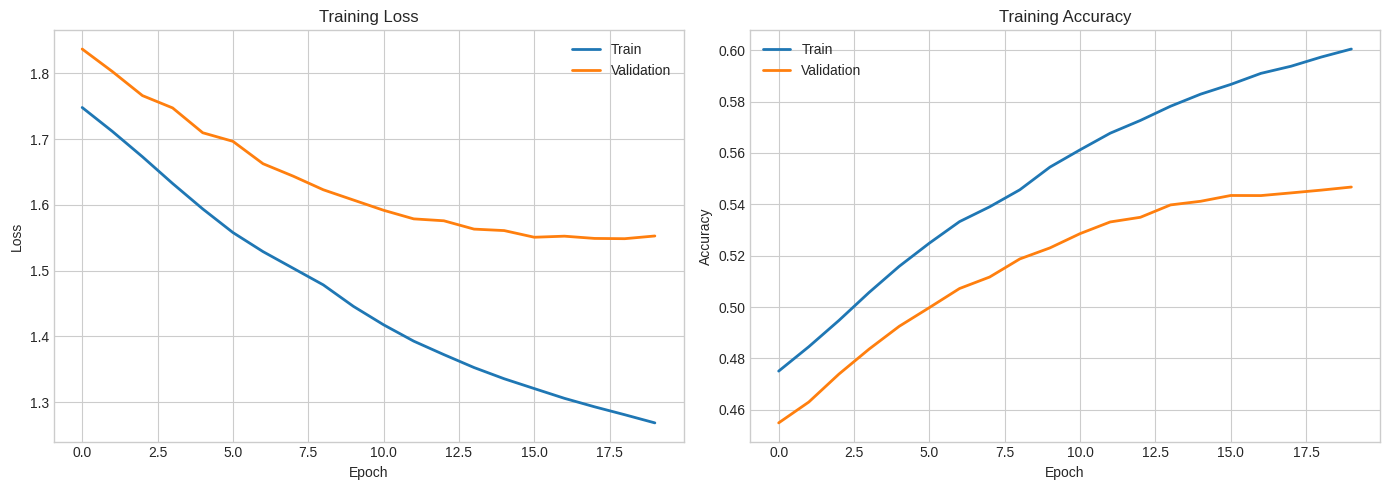

In [39]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [40]:
def generate_advanced(model, prompt, max_tokens=200, temperature=1.0, top_k=50, top_p=0.9):
    input_ids = encode(prompt)
    input_ids = list(input_ids)

    for _ in range(max_tokens):
        # Prepare input
        x = tf.constant([input_ids[-SEQ_LEN:]])

        # Get logits
        logits = model(x, training=False)
        next_logits = logits[0, -1, :].numpy()

        # Apply temperature
        next_logits = next_logits / temperature

        # Top-K filtering
        if top_k > 0:
            indices_to_remove = np.argsort(next_logits)[:-top_k]
            next_logits[indices_to_remove] = -np.inf

        # Top-P (nucleus) filtering
        if top_p < 1.0:
            sorted_indices = np.argsort(next_logits)[::-1]
            sorted_logits = next_logits[sorted_indices]
            probs = np.exp(sorted_logits) / np.sum(np.exp(sorted_logits))
            cumulative_probs = np.cumsum(probs)

            # Find cutoff
            cutoff_idx = np.searchsorted(cumulative_probs, top_p) + 1
            indices_to_remove = sorted_indices[cutoff_idx:]
            next_logits[indices_to_remove] = -np.inf

        # Convert to probabilities and sample
        probs = np.exp(next_logits) / np.sum(np.exp(next_logits))
        next_token = np.random.choice(len(probs), p=probs)

        input_ids.append(next_token)

    return decode(input_ids)

print("Advanced generation function ready")

Advanced generation function ready


In [44]:
# Import necessary modules if not already globally available in this cell's scope
import tensorflow as tf
from tensorflow import keras
import numpy as np # For .numpy() in get_config

# Register the custom learning rate schedule for Keras serialization
@tf.keras.utils.register_keras_serializable()
class WarmupSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, embed_dim, warmup_steps=4000):
        super().__init__()
        self.embed_dim = tf.cast(embed_dim, tf.float32)
        self.warmup_steps = warmup_steps

    def get_config(self):
        return {
            "embed_dim": self.embed_dim.numpy(),
            "warmup_steps": self.warmup_steps
        }

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.embed_dim) * tf.math.minimum(arg1, arg2)

# Load best model
model = keras.models.load_model('best_minigpt.keras', custom_objects={
    'MiniGPT': MiniGPT,
    'TransformerBlock': TransformerBlock,
    'CausalSelfAttention': CausalSelfAttention,
    'WarmupSchedule': WarmupSchedule # Explicitly add WarmupSchedule
})
print("Loaded best model")

Loaded best model


In [46]:
import numpy as np # Ensure numpy is imported if generate_advanced is moved
import tensorflow as tf # Ensure tensorflow is imported

# Compare sampling strategies
prompt = "ROMEO:\nO, she doth teach"

print("Comparing Sampling Strategies")
print("="*60)
print(f"Prompt: {prompt}")
print("="*60)

# Redefine generate_advanced with the fix for NaN probabilities
def generate_advanced(model, prompt, max_tokens=200, temperature=1.0, top_k=50, top_p=0.9):
    input_ids = encode(prompt)
    input_ids = list(input_ids)

    for _ in range(max_tokens):
        # Prepare input
        x = tf.constant([input_ids[-SEQ_LEN:]])

        # Get logits
        logits = model(x, training=False)
        next_logits = logits[0, -1, :].numpy()

        # Apply temperature
        # Ensure temperature is not too low (e.g. zero), to avoid division by zero or extreme values
        if temperature < 1e-6: # Using a small threshold instead of exact 0 for safety
            temperature = 1.0 # Fallback to default temperature if too low
        next_logits = next_logits / temperature

        # Top-K filtering
        if top_k > 0:
            # Ensure top_k does not exceed vocab size
            actual_top_k = min(top_k, len(next_logits))
            indices_to_remove = np.argsort(next_logits)[:-actual_top_k]
            next_logits[indices_to_remove] = -np.inf

        # Top-P (nucleus) filtering
        if top_p < 1.0:
            sorted_indices = np.argsort(next_logits)[::-1]
            sorted_logits = next_logits[sorted_indices]

            # Calculate probabilities for cumulative sum (numerically stable way)
            # Subtract max for numerical stability before exp
            # Filter out -inf logits before max, as max(-inf) is -inf
            finite_logits = sorted_logits[sorted_logits != -np.inf]
            if len(finite_logits) > 0:
                max_val_for_exp = np.max(finite_logits)
            else:
                max_val_for_exp = 0.0 # Fallback if all are -inf

            exp_sorted_logits = np.exp(sorted_logits - max_val_for_exp)
            sum_exp_sorted_logits = np.sum(exp_sorted_logits)

            if sum_exp_sorted_logits == 0:
                # Fallback if all exp_sorted_logits are zero (should be rare after max subtraction)
                probs_for_cumulative = np.ones_like(exp_sorted_logits) / len(exp_sorted_logits)
            else:
                probs_for_cumulative = exp_sorted_logits / sum_exp_sorted_logits

            cumulative_probs = np.cumsum(probs_for_cumulative)

            # Find cutoff
            # The searchsorted can return len(cumulative_probs) if value is larger than all elements
            # This would make cutoff_idx point beyond the array, needing care for sorted_indices slicing
            cutoff_idx = np.searchsorted(cumulative_probs, top_p)
            if cutoff_idx >= len(sorted_indices):
                 # If top_p is so high that all tokens are included, no tokens are removed by top_p
                 pass # No indices to remove by top_p beyond current state
            else:
                indices_to_remove_p = sorted_indices[cutoff_idx:]
                next_logits[indices_to_remove_p] = -np.inf

        # Convert to probabilities and sample (numerically stable softmax)
        # Subtract max logit before exp for numerical stability
        # Filter out -inf logits before max, as max(-inf) is -inf
        finite_logits_final = next_logits[next_logits != -np.inf]
        if len(finite_logits_final) > 0:
            max_val_for_exp_final = np.max(finite_logits_final)
        else:
            max_val_for_exp_final = 0.0 # Fallback if all are -inf

        exp_logits = np.exp(next_logits - max_val_for_exp_final)
        sum_exp_logits = np.sum(exp_logits)

        if sum_exp_logits == 0:
            # Fallback: if all exp_logits are zero (due to underflow or all -inf),
            # assign uniform probability to all tokens
            probs = np.ones_like(exp_logits) / len(exp_logits)
        else:
            probs = exp_logits / sum_exp_logits

        # If after all operations, probs contains NaN (e.g. if some weird edge case), make it uniform
        if np.any(np.isnan(probs)) or np.sum(probs) == 0: # Also check if sum is 0 (can happen with very small numbers)
            probs = np.ones_like(exp_logits) / len(exp_logits)
            probs = probs / np.sum(probs) # Ensure it sums to 1 after reset

        next_token = np.random.choice(len(probs), p=probs)

        input_ids.append(next_token)

    return decode(input_ids)

# Greedy (low temperature)
print("\n1. GREEDY (T=0.1):")
print("-" * 40)
print(generate_advanced(model, prompt, max_tokens=100, temperature=0.1, top_k=1, top_p=1.0))

# Normal temperature
print("\n2. NORMAL (T=1.0):")
print("-" * 40)
print(generate_advanced(model, prompt, max_tokens=100, temperature=1.0, top_k=50, top_p=0.9))

# Creative (high temperature)
print("\n3. CREATIVE (T=1.2):")
print("-" * 40)
print(generate_advanced(model, prompt, max_tokens=100, temperature=1.2, top_k=100, top_p=0.95))

Comparing Sampling Strategies
Prompt: ROMEO:
O, she doth teach

1. GREEDY (T=0.1):
----------------------------------------
ROMEO:
O, she doth teach the seasons of the seal'd the seal's death.

KING RICHARD II:
Why, then the seat of the sea that se

2. NORMAL (T=1.0):
----------------------------------------
ROMEO:
O, she doth teach ofUs it be to the motH--
SigUte noiUnty didFuarce.

KzIess:Kick yHad y the petiJulset,
No to havter

3. CREATIVE (T=1.2):
----------------------------------------
ROMEO:
O, she doth teach desig, 'here of tdread, by this last
Whosures witGremblinY my love.

QnUMTUSdrown:, I kF Catesble, 


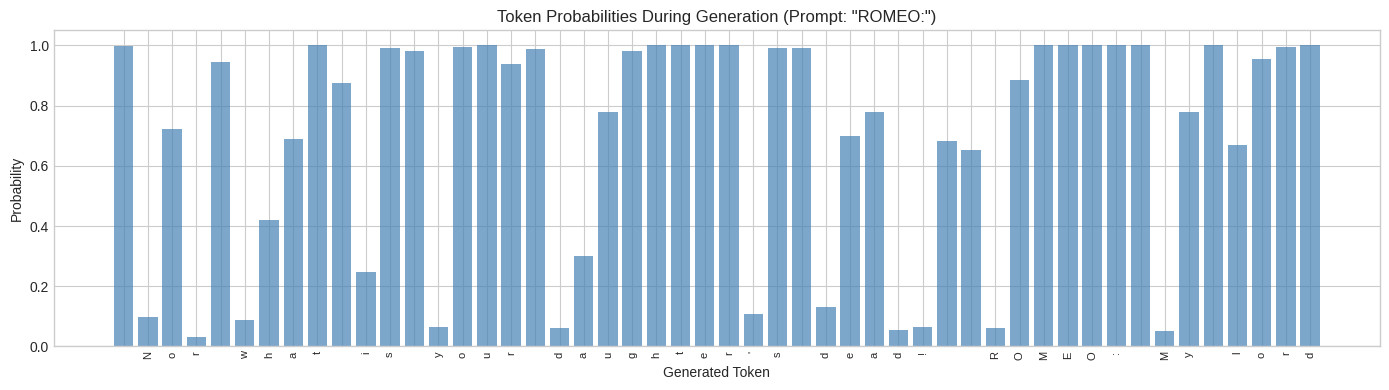


Generated: ROMEO:
Nor what is your daughter's dead!

ROMEO:
My lord


In [47]:
# Visualize token probabilities during generation
def generate_with_probs(model, prompt, max_tokens=20, temperature=1.0):
    input_ids = encode(prompt)
    input_ids = list(input_ids)

    tokens = []
    probabilities = []

    for _ in range(max_tokens):
        x = tf.constant([input_ids[-SEQ_LEN:]])
        logits = model(x, training=False)
        next_logits = logits[0, -1, :].numpy() / temperature

        probs = np.exp(next_logits) / np.sum(np.exp(next_logits))
        next_token = np.random.choice(len(probs), p=probs)

        tokens.append(idx2char[next_token])
        probabilities.append(probs[next_token])

        input_ids.append(next_token)

    return tokens, probabilities

# Generate and visualize
prompt = "ROMEO:"
tokens, probs = generate_with_probs(model, prompt, max_tokens=50, temperature=0.8)

plt.figure(figsize=(14, 4))
plt.bar(range(len(probs)), probs, color='steelblue', alpha=0.7)
plt.xticks(range(len(tokens)), tokens, rotation=90, fontsize=8)
plt.xlabel('Generated Token')
plt.ylabel('Probability')
plt.title(f'Token Probabilities During Generation (Prompt: "{prompt}")')
plt.tight_layout()
plt.show()

print(f"\nGenerated: {prompt}{''.join(tokens)}")

In [48]:
from google.colab import drive
import pickle

drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-54-text-generation'
os.makedirs(save_path, exist_ok=True)

# Save model
model.save(f'{save_path}/mini_gpt_shakespeare.keras')

# Save vocabulary
vocab_data = {'char2idx': char2idx, 'idx2char': idx2char, 'chars': chars}
with open(f'{save_path}/vocab.pkl', 'wb') as f:
    pickle.dump(vocab_data, f)

print(f"\nSaved to: {save_path}")
print("Files:")
print("  - mini_gpt_shakespeare.keras")
print("  - vocab.pkl")

Mounted at /content/drive

Saved to: /content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-54-text-generation
Files:
  - mini_gpt_shakespeare.keras
  - vocab.pkl
